### Task 4: Nested cross validation
#### **Objective**
In this lab, you will implement missing parts of a `NestedCrossValidator` class. This class performs nested cross-validation for hyperparameter tuning and model evaluation.

#### **Overview**
Nested cross-validation consists of two levels:
1. **Outer Cross-Validation**: Splits the dataset into training and test sets to evaluate model performance.
2. **Inner Cross-Validation**: Further splits the training data to perform hyperparameter tuning.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from itertools import product

class NestedCrossValidator:
    def __init__(self, model_class, param_grid, outer_splits=5, inner_splits=3, random_seed=None):
        """
        Initialize the nested cross-validator.

        :param model_class: The model class to be used (e.g., SVC, RandomForestClassifier).
        :param param_grid: Dictionary of hyperparameters and their values to search.
        :param outer_splits: Number of splits for the outer cross-validation.
        :param inner_splits: Number of splits for the inner cross-validation.
        :param random_seed: Random seed for reproducibility.
        """
        self.model_class = model_class
        self.param_grid = param_grid
        self.outer_splits = outer_splits
        self.inner_splits = inner_splits
        self.random_seed = random_seed

    def _create_folds(self, X, y, n_splits):
        """
        Manually create folds for cross-validation.

        :param X: Feature matrix.
        :param y: Target vector.
        :param n_splits: Number of splits for cross-validation.
        :return: List of (train_indices, test_indices) for each fold.
        """
        np.random.seed(self.random_seed)
        total_indices = np.arange(len(X))
        
        np.random.shuffle(total_indices)
        
        n = len(X)
        fold_size = n // n_splits
        remainder = n % n_splits
        folds = []
        start = 0
        for i in range(n_splits):
            extra = 1 if i < remainder else 0
            end = start + fold_size + extra
            test_indices = total_indices[start:end]
            train_indices = np.setdiff1d(total_indices, test_indices)
            folds.append((train_indices, test_indices))
            start = end
        print(total_indices)
        return folds

    def fit(self, X, y):
        """
        Perform nested cross-validation to evaluate model performance.

        :param X: Feature matrix.
        :param y: Target vector.
        :return: List of outer fold accuracies and mean accuracy.
        """
        outer_folds = self._create_folds(X, y, self.outer_splits)
        outer_results = []

        for outer_idx, (train_idx, test_idx) in enumerate(outer_folds):
            X_train = X[train_idx]
            X_test = X[test_idx]
            y_train = y[train_idx]
            y_test = y[test_idx]

            best_params = None
            best_score = -np.inf

            inner_folds = self._create_folds(X_train, y_train, self.inner_splits)

            for param_combination in product(*self.param_grid.values()):
                params = dict(zip(self.param_grid.keys(), param_combination))
                inner_scores = []

                for inner_train_idx, inner_val_idx in inner_folds:
                    X_inner_train = X_train[inner_train_idx]
                    X_inner_val = X_train[inner_val_idx]
                    y_inner_train = y_train[inner_train_idx]
                    y_inner_val = y[inner_val_idx]

                    model = self.model_class(**params)
                    model.fit(X_inner_train, y_inner_train)

                    inner_score = accuracy_score(y_inner_val, model.predict(X_inner_val))
                    inner_scores.append(inner_score)

                inner_mean = np.mean(inner_scores)
                if inner_mean > best_score:
                    best_params = params

            final_model = self.model_class(**best_params)
            final_model.fit(X_train, y_train)

            outer_accuracy = accuracy_score(y_test, final_model.predict(X_test))
            outer_results.append(outer_accuracy)

            print(f"Outer Fold {outer_idx + 1} - Best Params: {best_params}, Accuracy: {outer_accuracy:.4f}")

        mean_outer_accuracy = np.mean(outer_results)
        print(f"\nOverall Accuracy from Nested Cross-Validation: {mean_outer_accuracy:.4f}")
        return outer_results, mean_outer_accuracy
    
from sklearn.ensemble import RandomForestClassifier
X = np.arange(30).reshape(15, 2)
y = np.arange(30)
param_grid = {
    'n_estimators': [1, 2],
    'max_depth': [1, 2]
}

ncv = NestedCrossValidator(model_class=RandomForestClassifier, param_grid=param_grid)
res = ncv._create_folds(X, y, 4)

for r in res:
    print("Train/test:")
    for t in r:
        print(t)


[ 0  7 12  1 13 11  4  8  3  6 10  5  9  2 14]
Train/test:
[ 2  3  4  5  6  8  9 10 11 13 14]
[ 0  7 12  1]
Train/test:
[ 0  1  2  3  5  6  7  9 10 12 14]
[13 11  4  8]
Train/test:
[ 0  1  2  4  7  8  9 11 12 13 14]
[ 3  6 10  5]
Train/test:
[ 0  1  3  4  5  6  7  8 10 11 12 13]
[ 9  2 14]


Lets test if it works

Outer Fold 1 - Best Params: {'n_estimators': 100, 'max_depth': 50}, Accuracy: 0.9558
Outer Fold 2 - Best Params: {'n_estimators': 100, 'max_depth': 50}, Accuracy: 0.9558
Outer Fold 3 - Best Params: {'n_estimators': 100, 'max_depth': 50}, Accuracy: 0.9204
Outer Fold 4 - Best Params: {'n_estimators': 100, 'max_depth': 50}, Accuracy: 0.9735
Outer Fold 5 - Best Params: {'n_estimators': 100, 'max_depth': 50}, Accuracy: 0.9646

Overall Accuracy from Nested Cross-Validation: 0.9540


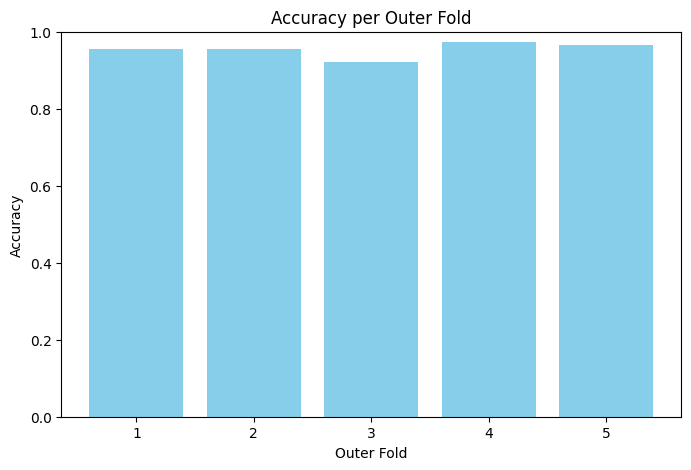

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

param_grid = {
    'n_estimators': [5, 10, 50, 100],
    'max_depth': [3, 5, 10, 20, 50]
}

nested_cv = NestedCrossValidator(model_class=RandomForestClassifier, param_grid=param_grid, outer_splits=5, inner_splits=3, random_seed=0)
outer_results, meanaccuracy = nested_cv.fit(X, y)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(outer_results) + 1), outer_results, color='skyblue')
plt.xlabel('Outer Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy per Outer Fold')
plt.ylim(0, 1.0)
plt.show()